# 3 Preprocessing and HP Search

This notebook is designed to clean, split and preprocess the dataset

Then, a Hyperparameter Search is performed

## 3.1 Imports

In [1]:
from pathlib import Path
import os

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import torch

import utilities as u

pd.options.display.max_rows = 1000
print(Path('..').absolute())

c:\Users\User\Askar\Thesis\..


## 3.2 Clean the Dataset

In [2]:
# Make a copy
df_complete = pd.read_csv('Files/database_v0.csv', sep='@', usecols=list(range(500)))

df_clean = df_complete.copy()
print(f'\nInitially: {len(df_clean)}')

# Remove duplicates in PDB IDs
print('\nRemoving PDB duplicates.')
df_clean = df_clean.drop_duplicates(subset=['basic$PDB ID'])
print(f'Left: {len(df_clean)}')

# Drop structures with artifacts
print('\nRemoving artifacts.')
scope_df = pd.read_csv('Files/SCOPe/2_08.csv')
scope_df['class'] = scope_df['class'].str.slice(0,1)
scope_df = scope_df.drop_duplicates(subset=['pdb_id'])
scope_df = scope_df.rename(columns={'pdb_id': 'basic$PDB ID'})
df_clean = pd.merge(df_clean, scope_df[['basic$PDB ID', 'class']], how='left', on='basic$PDB ID')
df_clean = df_clean.loc[(df_clean['class'] != 'l') & df_clean['class'].notna()]
print(f'Left: {len(df_clean)}')

# Remove not found in RCSB API
print('\nRemoving non-found in RCSB.')
df_clean = df_clean.loc[df_clean['basic$RCSB JSON'] == True]
print(f'Left: {len(df_clean)}')

# Remove not found Uniprots
print('\nRemoving non-found UniProts.')
df_clean = df_clean.loc[df_clean['UniProt'].notna()]
print(f'Left: {len(df_clean)}')

# Only leave the unique pairs
print('\nRemoving prot-ligand duplicates.')
df_clean['keys'] = df_clean['mol2$Derived Ligand'] + '_' + df_clean['UniProt']
df_clean = df_clean.drop_duplicates(subset=['keys'])
print(f'Left: {len(df_clean)}')


Initially: 17594

Removing PDB duplicates.
Left: 16612

Removing artifacts.
Left: 12689

Removing non-found in RCSB.
Left: 12681

Removing non-found UniProts.
Left: 12681

Removing prot-ligand duplicates.
Left: 9544


## 3.3 Split

Split on the protein level into 12 buckets by unique UniProts. Folds are stored as txt files into Files/Folds

In [3]:
u.split(
    df=df_clean,
    buckets=12,
    attribute_column='UniProt',
    exist_ok=True,
    dir='Files/Folds',
)

Splitting the data
There are in total 9544 datapoints
The expected number per bucket: 795 (12)
Already exixts
Bucket 0: 793 entries
Bucket 1: 802 entries
Bucket 2: 809 entries
Bucket 3: 794 entries
Bucket 4: 796 entries
Bucket 5: 793 entries
Bucket 6: 793 entries
Bucket 7: 793 entries
Bucket 8: 793 entries
Bucket 9: 793 entries
Bucket 10: 793 entries
Bucket 11: 792 entries
Bucket 101: 531 entries
Bucket 102: 131 entries
Bucket 103: 131 entries


## 3.4 Preprocessing

The proprocessing pipeline:
- aggregates protein file on residue level;
- takes each residue in a protein;
- cuts off a sphere of a predefined radius;
- creates a subgraph of the residues within the sphere;
- creates edges based on spatial proximity;
- node features are fixed features of amino-acids + some simple gemetrical features
- additionally, overall protein feature vector is computed

Numpy subgraph arrays are stored to the folder Files/Residues_Only_25_8/[entry]/resonly_[entry]\_res_[code][position]\_[chain]_[label].npy and a similar file for edges

    Note: the process might take several hours and take 5-10 Gb on disk

In [4]:
u.entries_to_samples(
    dir='Files/scPDB',
    dir_folds='Files/Folds',
    dir_save='Files/Residues_Only_25_8',
    cube_side=25,
    edge_radius=8,
    skip_existsing=True
);

Entries from Files/scPDB will be converted to samples and saves into Files/Residues_Only_25_8


Computing Samples fold 9.txt (0 b) ...: 100%|██████████| 793/793 [00:00<00:00, 2159.56it/s]

The total size of saved samples: 0 b


## 3.5 Hyperparameter Search

### 3.5.1 Broad Search Step

This search is run using small sub set (portion 10)

In [5]:
search_specification = {
    'encoder_hidden_dim': [16, 256],
    'encoder_depth': [1, 3],
    'gnn_hidden_dim': [16, 256],
    'gnn_depth': [1, 3],
    'dense_dim': [16, 256],
    'dense_depth': [1, 3]
}

selection = {'reduction': [1], 'use_folds': ['[101, 102, 103]'], 'epochs': [31]}


combined_dict = search_specification | selection
relevant_columns = list(combined_dict.keys())
df_logs = u.collect_logs()[relevant_columns + ['jaccard']].convert_dtypes()
df_logs = df_logs.loc[np.prod([df_logs[c].isin(combined_dict[c]).values for c in relevant_columns], axis=0).astype(bool)]
df_logs = df_logs.groupby(relevant_columns, as_index=False).sum()
expected_len = np.prod([len(set(v)) for v in list(combined_dict.values())])
real_len = len(df_logs)
if real_len < expected_len:
    search_performed = True
else:
    search_performed = False

In [6]:
if not search_performed:

    wrapper = u.TrainingWrapper(logs_dir='GNNLogs')
    wrapper.set_settings(verbose=1, device='cuda' if torch.cuda.is_available() else 'cpu', epochs=31)
    wrapper.initialize_dataset(use_folds=[101, 102, 103], reduction=1, dir_samples='Files/Residues_Only_25_8')
    wrapper.split_dataset(train_folds=[101], valid_folds=[102], test_folds=[103])

    u.hp_search(
        wrapper,
        **search_specification
    )


Let's show the metrics:

In [7]:
key_columns = ['encoder_hidden_dim', 'encoder_depth', 'gnn_hidden_dim', 'gnn_depth', 'dense_dim', 'dense_depth']
min_columns = ['mean_loss', 'cumulated_loss', 'total_params']
max_columns = ['average_precision', 'roc_auc', 'f1', 'accuracy', 'balanced_accuracy', 'recall', 'precision', 'jaccard']

df_grouped_min = u.subsample_logs(u.collect_logs(), combined_dict)
df_grouped_min =  df_grouped_min[[*key_columns, *min_columns]].groupby(key_columns, as_index=False).min()
df_grouped_max = u.subsample_logs(u.collect_logs(), combined_dict)
df_grouped_max =  df_grouped_max[[*key_columns, *max_columns]].groupby(key_columns, as_index=False).max()
df = pd.merge(left=df_grouped_min, right=df_grouped_max, how='left')
df

,encoder_hidden_dim,encoder_depth,gnn_hidden_dim,gnn_depth,dense_dim,dense_depth,mean_loss,cumulated_loss,total_params,average_precision,roc_auc,f1,accuracy,balanced_accuracy,recall,precision,jaccard
0,16,1,16,1,16,1,0.9266491,25.019526,3794,0.2798491854469682,0.7834973245216074,0.303897319339528,0.8128652814395546,0.7035257190165756,0.7265063228365981,0.2080358777228629,0.1791738924798991
1,16,1,16,1,16,3,0.9552348,25.79134,4402,0.238180166996324,0.7693779091091887,0.2571360721918784,0.7189660576338059,0.6933167287300004,0.7270022315893876,0.15902949124662202,0.1475365162415522
2,16,1,16,1,256,1,0.92524797,49.038143,17714,0.2914550411528414,0.7885494628483241,0.28993829800232146,0.785707701100684,0.709131872840604,0.7329531366228614,0.192363813229572,0.16954844241211775
3,16,1,16,1,256,3,0.9136934,193.703,150322,0.29302626176742763,0.7945840153198132,0.32287670202362145,0.8340493003189586,0.7159167507824619,0.6942722539052815,0.23174946004319655,0.19251816632277743
4,16,1,16,3,16,1,0.8964102,24.203075,7604,0.3173590927681333,0.8075683626059198,0.3498022182579694,0.8454433156953484,0.7346970526064402,0.7148524671460451,0.25451467268623024,0.21197593532618914
5,16,1,16,3,16,3,0.9085213,24.530075,8212,0.31073364882305615,0.8103616818025381,0.3656838304822488,0.8888069470307344,0.7348321320819765,0.7292338209769402,0.31022036474164133,0.22375341889333053
6,16,1,16,3,256,1,0.8598605,45.572605,21524,0.35421916506441464,0.8272999003095594,0.3555751302943551,0.8381422961337783,0.7504133330213367,0.7666749318125465,0.25255474452554744,0.21623069368806355
7,16,1,16,3,256,3,0.88420683,187.45184,154132,0.284929967831123,0.8191411488806954,0.3397575651870585,0.8691347554342816,0.7467518821216815,0.755516984874783,0.26203927898843155,0.20464334488916902
8,16,1,256,1,16,1,0.8987462,190.5342,281954,0.3048805058680205,0.800453036045423,0.3149543831812773,0.8089566548055827,0.7108360196209815,0.6337713860649641,0.21473000991616334,0.1869114877589454
9,16,1,256,1,16,3,0.90284187,191.40248,282562,0.31698456761190763,0.8016906521674219,0.3054099142040038,0.785062408967717,0.7175930060291446,0.7168361021572031,0.201003842835856,0.18022642570845931


Depth,1/1/1,1/1/3,1/3/1,1/3/3,3/1/1,3/1/3,3/3/1,3/3/3
Width,,,,,,,,
16/16/16,0.303897,0.257136,0.349802,0.365684,0.257263,0.261429,0.289067,0.293804
16/16/256,0.289938,0.322877,0.355575,0.339758,0.235365,0.282947,0.277158,0.348041
16/256/16,0.314954,0.305410,0.371613,0.320033,0.308158,0.295836,0.232585,0.233862
16/256/256,0.304198,0.328979,0.349797,0.413223,0.297246,0.287174,0.336218,0.299975
256/16/16,0.328498,0.312814,0.368972,0.349883,0.360420,0.316812,0.358534,0.354222
256/16/256,0.314942,0.313477,0.345585,0.362219,0.329516,0.330283,0.347284,0.357220
256/256/16,0.339230,0.341946,0.360356,0.365687,0.341733,0.343075,0.358866,0.363279
256/256/256,0.321646,0.328706,0.379694,0.355503,0.336512,0.338981,0.369251,0.364949


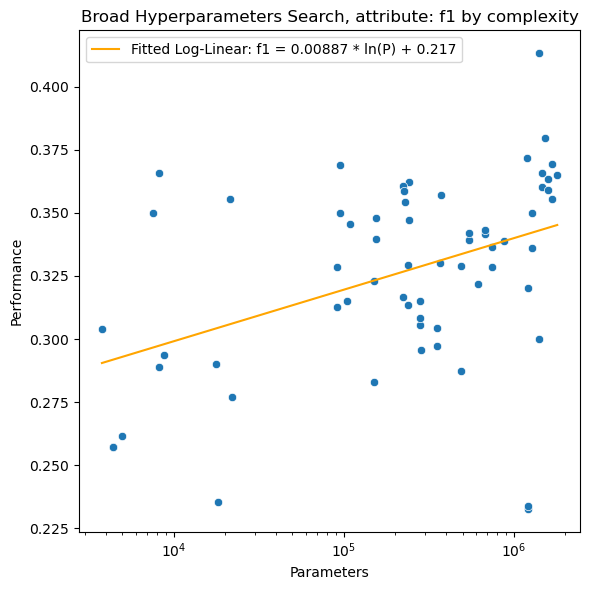

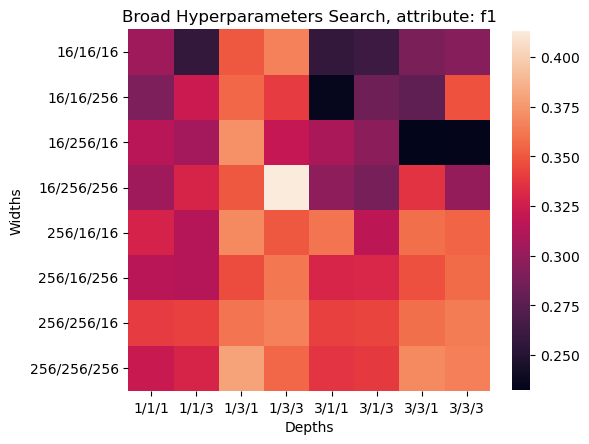

In [8]:
u.plot_broad_hp(df=df, target_column='f1', figsize=(6, 6))


### 3.5.2 HP Fine Search

In [9]:
search_specification = {
    'gnn_activation': ['relu', 'leakyrelu', 'elu'],
    'dropout': [0.1, 0.2],
    'lr': [1e-3, 1e-4],
    'pos_weight':  [6, 8, 10],
}

selection = {'reduction': [1], 'use_folds': ['[101, 102, 103]'], 'epochs': [32], 
             'encoder_hidden_dim': [16], 'encoder_depth': [1], 'gnn_hidden_dim': [256],
            'gnn_depth': [3], 'dense_dim': [256], 'dense_depth': [3]}


combined_dict = search_specification | selection
relevant_columns = list(combined_dict.keys())
df_logs = u.collect_logs()[relevant_columns + ['jaccard']].convert_dtypes()
df_logs = df_logs.loc[np.prod([df_logs[c].isin(combined_dict[c]).values for c in relevant_columns], axis=0).astype(bool)]
df_logs = df_logs.groupby(relevant_columns, as_index=False).sum()
expected_len = np.prod([len(set(v)) for v in list(combined_dict.values())])
real_len = len(df_logs)
if real_len < expected_len:
    search_performed = True
else:
    search_performed = False

In [10]:
if not search_performed:

    wrapper = u.TrainingWrapper(logs_dir='GNNLogs')
    wrapper.set_settings(verbose=1, device='cuda' if torch.cuda.is_available() else 'cpu', epochs=32)
    wrapper.initialize_dataset(use_folds=[101, 102, 103], reduction=1, dir_samples='Files/Residues_Only_25_8')
    wrapper.split_dataset(train_folds=[101], valid_folds=[102], test_folds=[103])

    u.hp_search(
        wrapper,
        **search_specification | {'encoder_hidden_dim': [16], 'encoder_depth': [1], 'gnn_hidden_dim': [256],
                                  'gnn_depth': [3], 'dense_dim': [256], 'dense_depth': [3]}
    )

In [11]:
key_columns = ['gnn_activation', 'dense_activation', 'dropout', 'lr', 'pos_weight']
min_columns = ['mean_loss', 'cumulated_loss', 'total_params']
max_columns = ['average_precision', 'roc_auc', 'f1', 'accuracy', 'balanced_accuracy', 'recall', 'precision', 'jaccard']

logs = u.collect_logs()
logs['pos_weight'] = logs['pos_weight'].apply(lambda x: float(eval(x.replace('cuda', 'cpu'), {}, {'tensor': torch.tensor})))
df_grouped_min = u.subsample_logs(logs, combined_dict)
df_grouped_min =  df_grouped_min[[*key_columns, *min_columns]].groupby(key_columns, as_index=False).min()
df_grouped_max = u.subsample_logs(logs, combined_dict)
df_grouped_max =  df_grouped_max[[*key_columns, *max_columns]].groupby(key_columns, as_index=False).max()
df = pd.merge(left=df_grouped_min, right=df_grouped_max, how='left')
df

,gnn_activation,dense_activation,dropout,lr,pos_weight,mean_loss,cumulated_loss,total_params,average_precision,roc_auc,f1,accuracy,balanced_accuracy,recall,precision,jaccard
0,elu,elu,0.1,0.0001,6,0.61832035,262.16782,1407172,0.3568662318522484,0.8550909874426711,0.401441688835493,0.8966242002986781,0.7657743822206785,0.7242747334490454,0.3283668730650155,0.2511273351943311
1,elu,elu,0.1,0.0001,8,0.7004883,297.00705,1407172,0.3563822395284295,0.8618366764832683,0.4030157642220699,0.8875901104371393,0.7715518164838524,0.7835358294073891,0.33300970873786406,0.25236051502145923
2,elu,elu,0.1,0.0001,10,0.7943376,336.79913,1407172,0.3676758313618747,0.8596012398173185,0.3868915520047344,0.8577960508121463,0.7799776179270095,0.7912224150756261,0.27921766258699304,0.23984224525359993
3,elu,elu,0.1,0.001,6,0.6469691,274.31488,1407172,0.3236630319599308,0.830711789272976,0.4153512233622731,0.9255517247736869,0.7342063863260753,0.5901314158194892,0.49584026622296173,0.2621093263603536
4,elu,elu,0.1,0.001,8,0.77994645,330.6973,1407172,0.31523356285269705,0.8298895804430798,0.3938425791460935,0.9133649219196519,0.7355210665457768,0.6900570295065708,0.33759970320905214,0.24520795660036165
5,elu,elu,0.1,0.001,10,0.9272098,393.13696,1407172,0.2591946922508098,0.8028432552898176,0.3523781475482256,0.9176422869153192,0.734478673874053,0.8036201338953632,0.31703204047217537,0.2138707659308249
6,elu,elu,0.2,0.0001,6,0.6419133,272.17123,1407172,0.3389720452823977,0.8497467868533392,0.39557469808293216,0.8811187521893841,0.7531716933474354,0.6898090751301761,0.3170177299590847,0.24655226865985894
7,elu,elu,0.2,0.0001,8,0.7286042,308.9282,1407172,0.3641825602891323,0.8489987554276628,0.39182973415451783,0.8625343387599329,0.7769780717675757,0.7822960575254153,0.2857630202410735,0.24364940857087453
8,elu,elu,0.2,0.0001,10,0.7982647,338.46423,1407172,0.36155211270385573,0.8575319250766683,0.3797647725662463,0.8396541234167296,0.7744980489458562,0.7974212744854947,0.26584664219819465,0.23438866538394262
9,elu,elu,0.2,0.001,6,0.85909235,364.25516,1407172,0.13766720270492075,0.7070689537681494,0.06688717383314957,0.9256439093641107,0.5103441932306094,0.045127696503843295,0.12916962384669978,0.03460076045627376


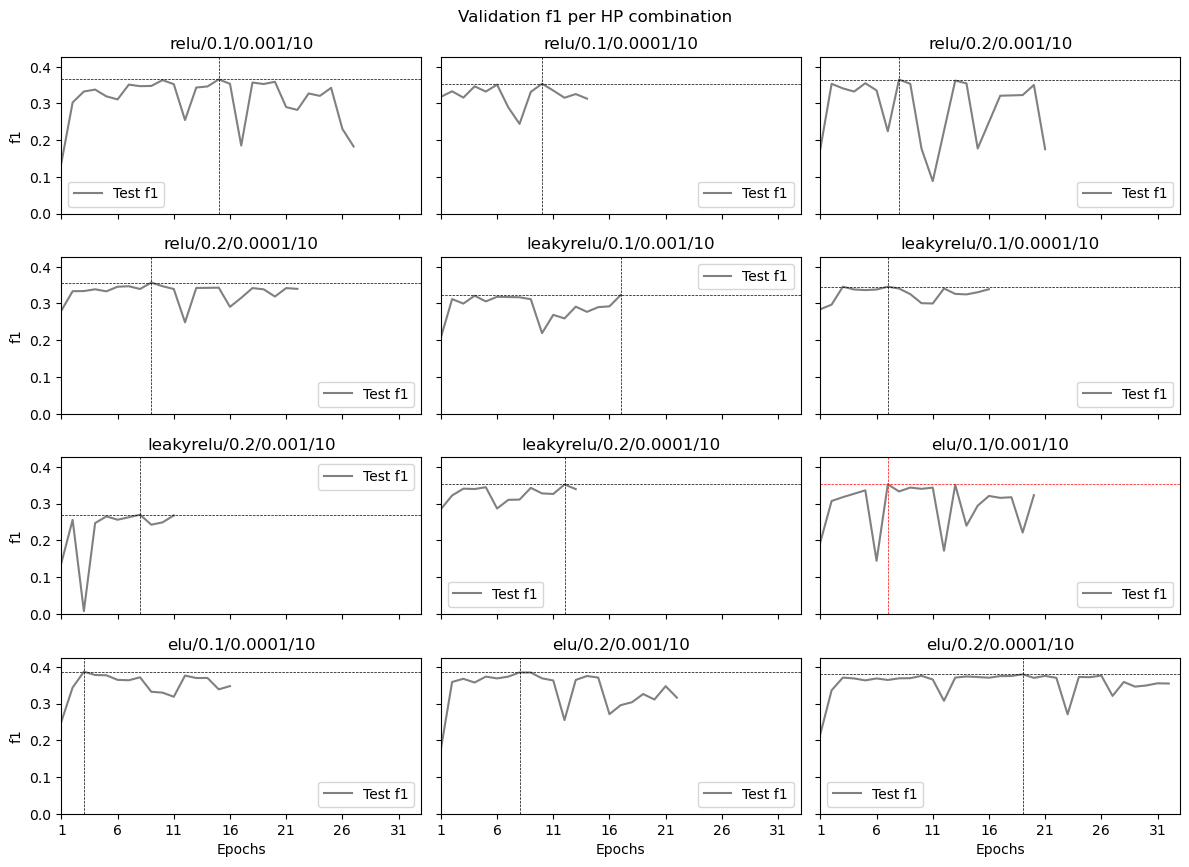

In [17]:
u.analyse_hyperparameters(
    df=u.subsample_logs(logs, {'pos_weight': [10], 'epochs': [32], 'reduction': [1]}),
    param_columns=[c for c in key_columns if c != 'dense_activation'],
    target_column='f1',
    save=None);